<a href="https://colab.research.google.com/github/eniolapeter6356/vncworldwide/blob/main/Gans_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data trial on GANS

# Data trial on GANS and IMport Libraries


In [ ]:
# Basic libraries
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter("ignore", DeprecationWarning)
warnings.simplefilter("ignore", FutureWarning)

## Models
from sklearn import tree
from sklearn import ensemble
from sklearn.model_selection import GridSearchCV
from sklearn.manifold import TSNE

## Model Explaination
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay

# import linear models and some convenience functions to create dummy data, plot decision boundaries ad split train and test data
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, SplineTransformer
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
import sklearn.metrics.pairwise as pairwise
from sklearn.kernel_ridge import KernelRidge

## Metrics
from sklearn.metrics import accuracy_score, confusion_matrix

# Plotting
import graphviz
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# 1.2 Load Data Correctly (Python)


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving soil_data.csv to soil_data (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv("soil_data.csv")
df.head()


,idx,Fcode,CODE,PH,OC,P,K,Mg,Ca,Na,...,spc.1691,spc.1692,spc.1693,spc.1694,spc.1695,spc.1696,spc.1697,spc.1698,spc.1699,spc.1700
0,1,Dal,Dal1,7.2,14.1,31,54,27,303,7.8,...,29.186804,28.966117,28.451317,27.940445,27.454920,27.164706,27.138953,27.474241,27.674517,27.689306
1,2,Dal,Dal2,7.5,12.9,36,52,44,687,16.0,...,44.767169,44.686953,44.964373,45.031159,44.687657,44.511208,44.623283,45.318648,45.063533,43.813080
2,3,Dal,Dal3,6.9,14.3,43,58,32,298,30.0,...,27.693393,27.520943,28.467363,28.749614,27.936924,27.065986,26.482845,26.500586,26.760343,27.295907
3,4,Dal,Dal4,7.5,12.4,43,45,38,581,26.0,...,29.986438,29.967014,29.959293,29.857686,29.671480,29.333505,28.882695,28.252625,28.324140,29.174932
4,5,Dal,Dal5,6.8,15.0,33,38,28,315,13.2,...,31.527553,31.138590,30.402295,29.994889,30.112991,30.543460,31.198313,31.970370,32.609870,32.958428


# 1.3 Separate Metadata, Targets & Spectra

In [ ]:
# metadata
meta_cols = ['idx','Fcode','CODE']

# soil properties
target_cols = ['PH','OC','P','K','Mg','Ca','Na','MC','CEC']

# spectral columns
spectral_cols = [col for col in df.columns if col.startswith('spc.')]

meta = df[meta_cols]
targets = df[target_cols]
spectra = df[spectral_cols]


In [ ]:
print(meta.shape)
print(targets.shape)
print(spectra.shape)


(372, 3)
(372, 9)
(372, 1396)


# 1.4 Check for Missing Values

In [ ]:
df.isna().sum()


,0
idx,0
Fcode,0
CODE,0
PH,0
OC,0
...,...
spc.1696,0
spc.1697,0
spc.1698,0
spc.1699,0


# 1.5 Ensure Numeric Data Types

In [ ]:
spectra = spectra.astype(float)
targets = targets.astype(float)


# 1.6 Inspect Value Ranges (important)

I Look for:

impossible values

extreme outliers

different units (e.g., Ca much larger than Mg → normal)

In [ ]:
targets.describe()


,PH,OC,P,K,Mg,Ca,Na,MC,CEC
count,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000
mean,7.158871,20.706586,28.150538,30.145161,42.935484,1010.870968,6.315591,20.103175,55.169080
std,0.578689,19.197047,9.320234,10.456193,26.673349,977.739127,4.319039,7.214885,50.467487
min,5.000000,7.700000,8.000000,10.000000,7.000000,83.000000,1.100000,5.200000,5.920000
25%,6.800000,11.900000,21.000000,23.000000,18.000000,230.750000,3.500000,15.550144,14.407500
50%,7.300000,14.100000,28.000000,28.000000,38.000000,668.000000,5.100000,19.796354,37.971990
75%,7.600000,18.400000,34.000000,36.000000,67.000000,1560.750000,7.700000,22.975000,85.033166
max,8.200000,166.000000,69.000000,69.000000,108.000000,4550.000000,30.000000,48.101732,235.105073


# 1.7 Confirm Spectral Order



Check wavelengths:They should increase sequentially.

This ensures correct spectral structure.

In [ ]:
print(spectral_cols[:10])


['spc.305', 'spc.306', 'spc.307', 'spc.308', 'spc.309', 'spc.310', 'spc.311', 'spc.312', 'spc.313', 'spc.314']


# 1.8 Save Clean Dataset Version

In [ ]:
df_clean = pd.concat([meta, targets, spectra], axis=1)
df_clean.to_csv("soil_clean.csv", index=False)


In [ ]:
spectra.dtypes.unique()


array([dtype('float64')], dtype=object)

In [ ]:
spectral_cols[:5], spectral_cols[-5:]


(['spc.305', 'spc.306', 'spc.307', 'spc.308', 'spc.309'],
 ['spc.1696', 'spc.1697', 'spc.1698', 'spc.1699', 'spc.1700'])

# STEP 2 — SPECTRAL QUALITY CONTROL & VISUALIZATION

# 2.1 Plot Raw Spectral Curves

. Why?

detect noise, detect spikes, detect instrument issues, observe soil variability

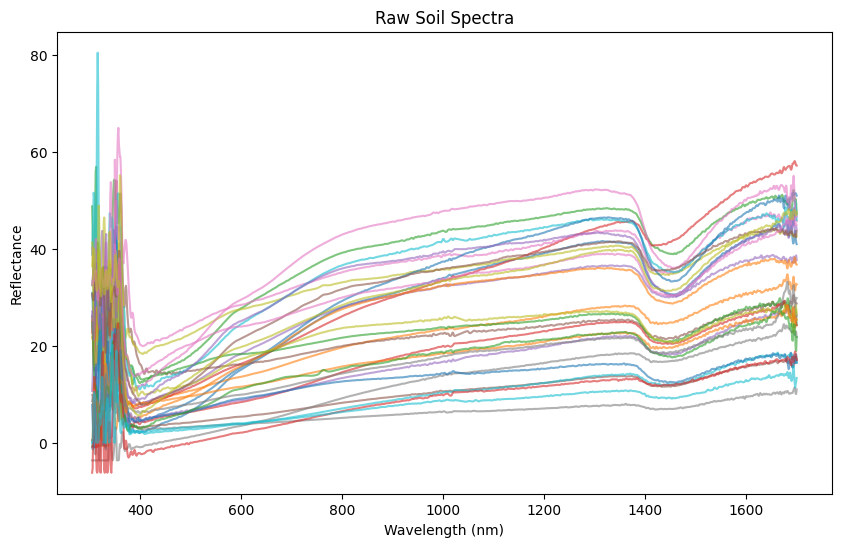

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# convert column names to wavelengths
wavelengths = np.array([float(col.split('.')[1]) for col in spectral_cols])

# plot 30 random spectra
plt.figure(figsize=(10,6))

for i in np.random.choice(len(spectra), 30, replace=False):
    plt.plot(wavelengths, spectra.iloc[i], alpha=0.6)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Raw Soil Spectra")
plt.show()


# 2.2 Plot Mean Spectrum + Variability

This reveals overall spectral behavior. What this reveals
✔ wavelengths with strong variability
✔ useful regions for prediction
✔ sensor noise zones

In [ ]:
from scipy.spatial.distance import euclidean

mean_vec = spectra.mean(axis=0)

distances = spectra.apply(lambda row: euclidean(row, mean_vec), axis=1)

# threshold: top 2% farthest
threshold = np.percentile(distances, 98)

outliers = distances > threshold
print("Outliers found:", outliers.sum())


Outliers found: 8


Visualize outliers but i discovered that they contain real spectral info and maybe from different soil from other....mineral soil maybe

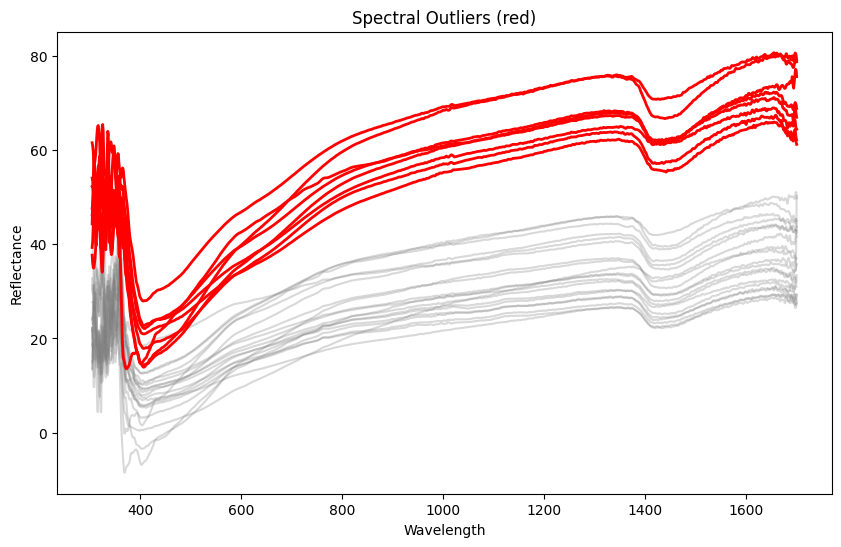

In [ ]:
plt.figure(figsize=(10,6))

# normal
for i in np.where(~outliers)[0][:20]:
    plt.plot(wavelengths, spectra.iloc[i], color='gray', alpha=0.3)

# outliers
for i in np.where(outliers)[0]:
    plt.plot(wavelengths, spectra.iloc[i], color='red', linewidth=2)

plt.title("Spectral Outliers (red)")
plt.xlabel("Wavelength")
plt.ylabel("Reflectance")
plt.show()


# 2.4 Compare Spectra by Site (Very Important)

The dtaset has:

Dal, Kat, (possibly others)....This is perfect for domain analysis.

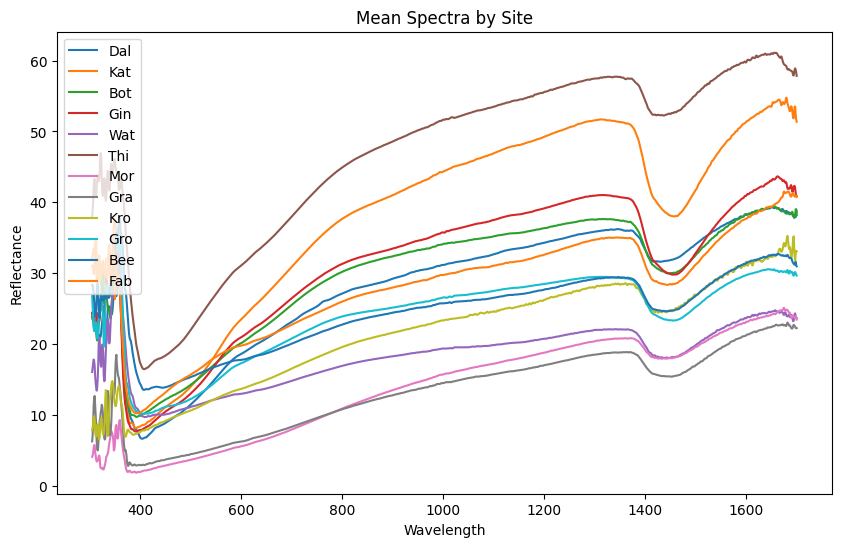

In [ ]:
plt.figure(figsize=(10,6))

for site in meta['Fcode'].unique():
    idx = meta['Fcode'] == site
    plt.plot(wavelengths,
             spectra[idx].mean(axis=0),
             label=site)

plt.legend()
plt.title("Mean Spectra by Site")
plt.xlabel("Wavelength")
plt.ylabel("Reflectance")
plt.show()


# 2.5 Identify Noisy Wavelength Regions

I Look for: high variance spikes AND noisy edges. Typical noise regions

Often:extreme ends, water absorption zones, sensor boundaries

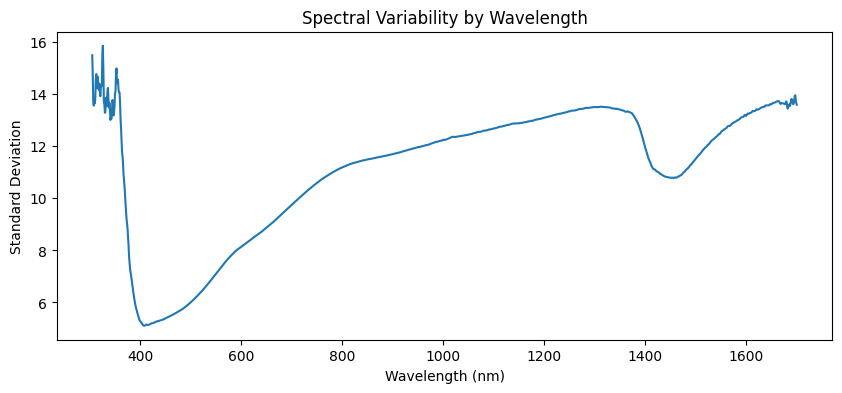

In [ ]:


# wavelengths
wavelengths = np.array([float(col.split('.')[1]) for col in spectral_cols])

# mean & std
mean_spec = spectra.mean(axis=0)
std_spec = spectra.std(axis=0)

# plot variability
plt.figure(figsize=(10,4))
plt.plot(wavelengths, std_spec)
plt.title("Spectral Variability by Wavelength")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Standard Deviation")
plt.show()


# STEP 3 — SPECTRAL PREPROCESSING (MODEL + GAN READY)

The Goal
Create two spectral versions:
ML version; best for prediction accuracy
GAN version ; best for stable generation + physical realism
Keeping both is normal in research.

# 3.1 Fix the wavelength order + convert to array

Ensures your spectral matrix is clean

In [ ]:


# ensure spectral columns are sorted by wavelength
spectral_cols = sorted(spectral_cols, key=lambda x: float(x.split('.')[1]))

wavelengths = np.array([float(c.split('.')[1]) for c in spectral_cols])

X_raw = spectra[spectral_cols].to_numpy(dtype=np.float32)   # (n_samples, n_bands)


# 3.2 Remove noisy edges (recommended)

From the plot, the very short wavelengths (~305–380 nm) often look noisy.
A safe VIS–NIR start:
✅ keep 380–1700 nm

In [ ]:
mask = (wavelengths >= 380) & (wavelengths <= 1700)
wavelengths2 = wavelengths[mask]
X_raw2 = X_raw[:, mask]
print(X_raw2.shape)



(372, 1321)


# 3.3 “ML preprocessing” pipeline (SNV + optional SavGol)

Using Savitzky–Golay + SNV

SavGol smooths noise

SNV removes scatter effects

In [ ]:
from scipy.signal import savgol_filter

# SavGol smoothing (light)
X_smooth = savgol_filter(X_raw2, window_length=11, polyorder=2, axis=1)

# SNV: (x - mean) / std per sample
X_m = X_smooth.mean(axis=1, keepdims=True)
X_s = X_smooth.std(axis=1, keepdims=True) + 1e-8
X_ML = (X_smooth - X_m) / X_s


# 3.4 Make a “GAN preprocessing” pipeline (scale to [-1, 1])

GANs train best when inputs are bounded and consistent.

Start from the smoothed spectra (no SNV for GAN at first)`. I save xmin and xmax. So, I must use them later to invert scaling and to scale generated spectra.

In [ ]:
X_for_gan = X_smooth

# scale to [-1, 1] using min/max across the whole dataset
xmin = X_for_gan.min()
xmax = X_for_gan.max()

X_GAN = 2 * (X_for_gan - xmin) / (xmax - xmin + 1e-8) - 1


# 3.5 Quick check: plot before vs after

I tried to confirm preprocessing didn’t distort physics.

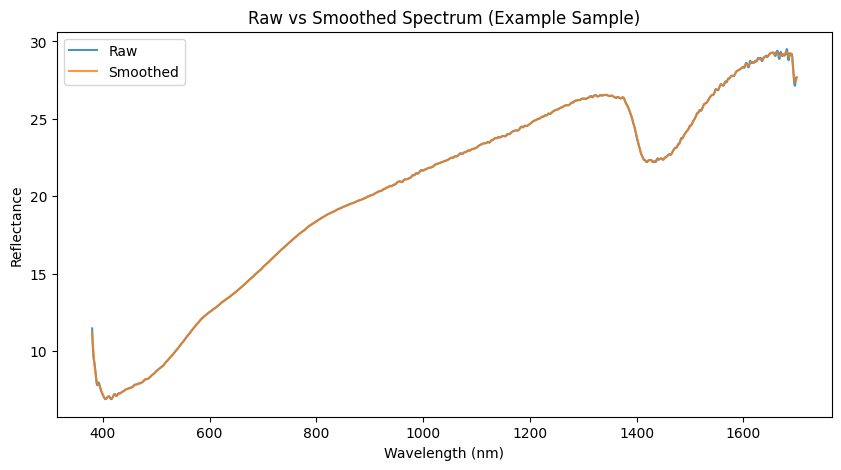

In [ ]:


i = 0  # sample index
plt.figure(figsize=(10,5))
plt.plot(wavelengths2, X_raw2[i], label="Raw", alpha=0.8)
plt.plot(wavelengths2, X_smooth[i], label="Smoothed", alpha=0.8)
plt.legend()
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Raw vs Smoothed Spectrum (Example Sample)")
plt.show()


# 3.6 Save the processed arrays (very important)

In [ ]:


np.save("wavelengths.npy", wavelengths2)
np.save("X_ML.npy", X_ML)
np.save("X_GAN.npy", X_GAN)
np.save("targets.npy", targets.to_numpy(dtype=np.float32))

# save scaler for GAN inverse transform later
np.save("gan_minmax.npy", np.array([xmin, xmax], dtype=np.float32))


# Step 4: Baseline Prediction Models (OC, CEC, moisture)

# Step 4B — Site-based split (by Fcode)

This is the most important part.

In [ ]:


# meta must contain Fcode
groups = meta["Fcode"].astype(str).to_numpy()

# Pick one site to hold out for testing (example: last unique)
unique_sites = pd.unique(groups)
test_site = unique_sites[-1]         # you can change this
test_mask = groups == test_site

X_train, X_test = X_ML[~test_mask], X_ML[test_mask]

y = targets.copy()
y_train = y.loc[~test_mask, ["OC","MC","CEC"]].to_numpy(dtype=np.float32)
y_test  = y.loc[test_mask,  ["OC","MC","CEC"]].to_numpy(dtype=np.float32)

print("Test site:", test_site)
print("Train samples:", X_train.shape[0], "Test samples:", X_test.shape[0])


Test site: Fab
Train samples: 347 Test samples: 25


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_ML, targets[["OC","MC","CEC"]].values,
    test_size=0.2,
    random_state=42
)




```
# This is formatted as code
```

# Step 4C :  Baseline 1: PLSR (most spectroscopy standard)

In [ ]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def eval_reg(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

targets_list = ["OC","MC","CEC"]

results = []

# choose components (start with 20; later tune)
n_comp = 8

for j, name in enumerate(targets_list):
    pls = PLSRegression(n_components=n_comp)
    pls.fit(X_train, y_train[:, j])
    pred = pls.predict(X_test).ravel()

    rmse, mae, r2 = eval_reg(y_test[:, j], pred)
    results.append(["PLSR", name, rmse, mae, r2])

results_df = pd.DataFrame(results, columns=["Model","Target","RMSE","MAE","R2"])
results_df


,Model,Target,RMSE,MAE,R2
0,PLSR,OC,10.198728,7.821594,0.324712
1,PLSR,MC,4.787144,3.739339,0.536467
2,PLSR,CEC,25.961020,19.901932,0.666633


In [ ]:
print(test_site)
print(targets.groupby(meta["Fcode"]).mean())


Fab
             PH         OC          P          K         Mg           Ca  \
Fcode                                                                      
Bee    7.615385  12.939744  32.692308  26.076923  64.974359  1642.051282   
Bot    5.864000  16.036000  25.680000  27.120000  16.880000   164.800000   
Dal    7.073913  14.708696  32.869565  39.173913  26.565217   344.652174   
Fab    7.648000  13.164000  32.240000  29.920000  80.280000  2990.320000   
Gin    6.889474  13.447368  26.105263  39.868421  19.421053   240.105263   
Gra    7.387500  38.687500  28.062500  25.000000  40.531250   911.687500   
Gro    6.873333  11.603333  22.066667  24.750000  14.350000   230.716667   
Kat    7.230000  13.780000  32.350000  43.100000  21.850000   326.600000   
Kro    7.621739  16.534783  31.152174  27.478261  74.782609  1752.695652   
Mor    7.180645  69.645161  16.000000  31.677419  70.064516  1034.967742   
Thi    6.546154  16.576923  36.538462  42.000000  18.846154   238.846154   
Wat    7

# Step 4D — Baseline 2: Random Forest (strong nonlinear baseline)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

def eval_reg(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

targets_list = ["OC","MC","CEC"]
results = []

for j, name in enumerate(targets_list):
    rf = RandomForestRegressor(
        n_estimators=300,      # increase later if you want
        max_features="sqrt",  # key for spectral data
        min_samples_leaf=2,
        random_state=42,
        n_jobs=1              # change to -1 if your machine handles it
    )
    rf.fit(X_train, y_train[:, j])
    pred = rf.predict(X_test)

    rmse, mae, r2 = eval_reg(y_test[:, j], pred)
    results.append(["RandomForest", name, rmse, mae, r2])

rf_df = pd.DataFrame(results, columns=["Model","Target","RMSE","MAE","R2"])
rf_df


,Model,Target,RMSE,MAE,R2
0,RandomForest,OC,8.171970,4.713712,0.566439
1,RandomForest,MC,4.102119,2.743669,0.659636
2,RandomForest,CEC,22.006422,14.364791,0.760460


# STEP 4E — Combine & Compare Models

In [ ]:
all_results = pd.concat([results_df, rf_df], ignore_index=True)

# sort for easy comparison
all_results = all_results.sort_values(["Target","R2"], ascending=[True, False])

all_results


,Model,Target,RMSE,MAE,R2
5,RandomForest,CEC,22.006422,14.364791,0.760460
2,PLSR,CEC,25.961020,19.901932,0.666633
4,RandomForest,MC,4.102119,2.743669,0.659636
1,PLSR,MC,4.787144,3.739339,0.536467
3,RandomForest,OC,8.171970,4.713712,0.566439
0,PLSR,OC,10.198728,7.821594,0.324712


# STEP 4F — Scatter Plots (Thesis Figures)

4F.1 Plot function

In [ ]:
import matplotlib.pyplot as plt

def scatter_plot(y_true, y_pred, title):
    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred, alpha=0.7)
    m = min(y_true.min(), y_pred.min())
    M = max(y_true.max(), y_pred.max())
    plt.plot([m, M], [m, M])
    plt.xlabel("Measured")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.show()


4F.2 Plot BEST model for each target
⭐ OC

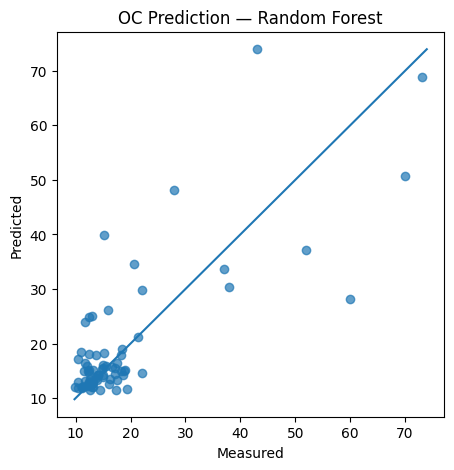

In [ ]:
best_rf_oc = RandomForestRegressor(
    n_estimators=300,
    max_features="sqrt",
    min_samples_leaf=2,
    random_state=42,
    n_jobs=1
)
best_rf_oc.fit(X_train, y_train[:,0])
pred_oc = best_rf_oc.predict(X_test)

scatter_plot(y_test[:,0], pred_oc, "OC Prediction — Random Forest")


⭐ MC

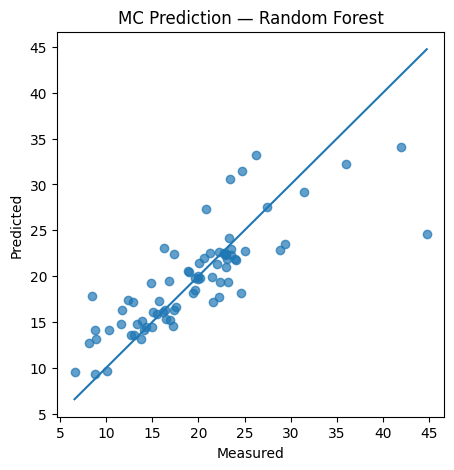

In [ ]:
best_rf_mc = RandomForestRegressor(
    n_estimators=300,
    max_features="sqrt",
    min_samples_leaf=2,
    random_state=42,
    n_jobs=1
)
best_rf_mc.fit(X_train, y_train[:,1])
pred_mc = best_rf_mc.predict(X_test)

scatter_plot(y_test[:,1], pred_mc, "MC Prediction — Random Forest")


⭐ CEC

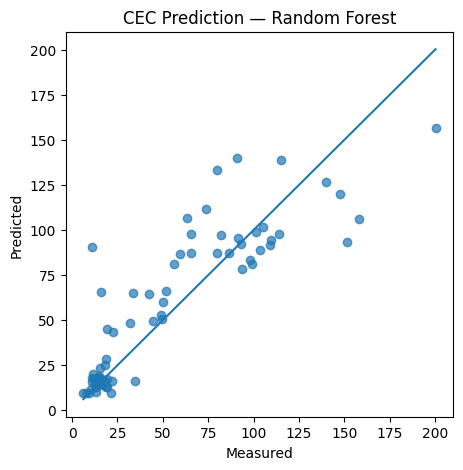

In [ ]:
best_rf_cec = RandomForestRegressor(
    n_estimators=300,
    max_features="sqrt",
    min_samples_leaf=2,
    random_state=42,
    n_jobs=1
)
best_rf_cec.fit(X_train, y_train[:,2])
pred_cec = best_rf_cec.predict(X_test)

scatter_plot(y_test[:,2], pred_cec, "CEC Prediction — Random Forest")


IMPORTANT: Save baseline results

In [ ]:
all_results.to_csv("baseline_results.csv", index=False)


# Step 5: Spectral Space Analysis & Clustering

# STEP 5.1 — Dimensionality Reduction (PCA)

1396 bands → too high dimensional.
PCA reveals spectral structure.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_ML)

print("Explained variance (first 5 PCs):")
print(pca.explained_variance_ratio_[:5])


Explained variance (first 5 PCs):
[0.7127939  0.12021387 0.07120965 0.03375474 0.0225955 ]


# STEP 5.2 — PCA Scatter Plot (critical figure)

Plot PC1 vs PC2

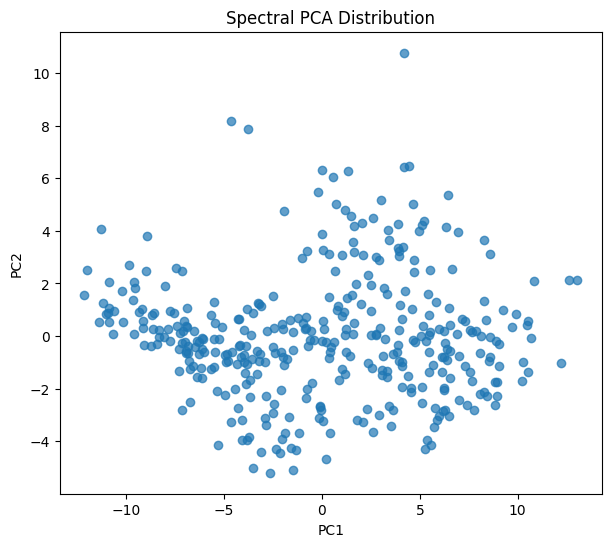

In [ ]:


plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Spectral PCA Distribution")
plt.show()


# STEP 5.3 — Color PCA by SITE (very important)

This reveals domain differences.

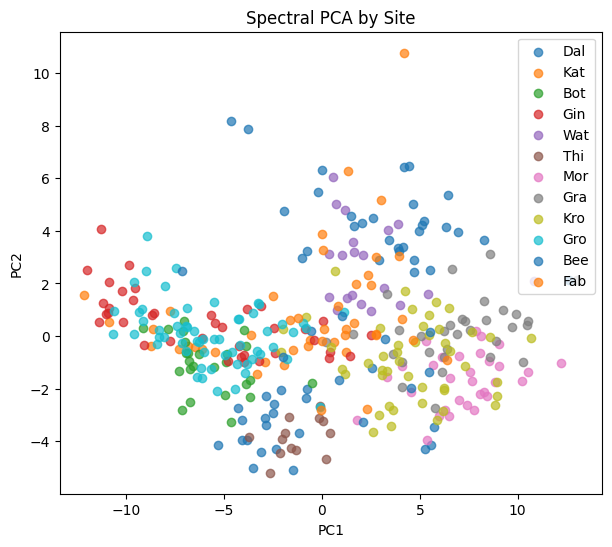

In [ ]:
plt.figure(figsize=(7,6))

for site in meta["Fcode"].unique():
    idx = meta["Fcode"] == site
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=site, alpha=0.7)

plt.legend()
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Spectral PCA by Site")
plt.show()


# STEP 5.4 — Color PCA by OC (reveals gradients)

What to observe
✔ gradient → spectra capture OC
✔ clustering → mineral masking
✔ mixed pattern → nonlinear relationships

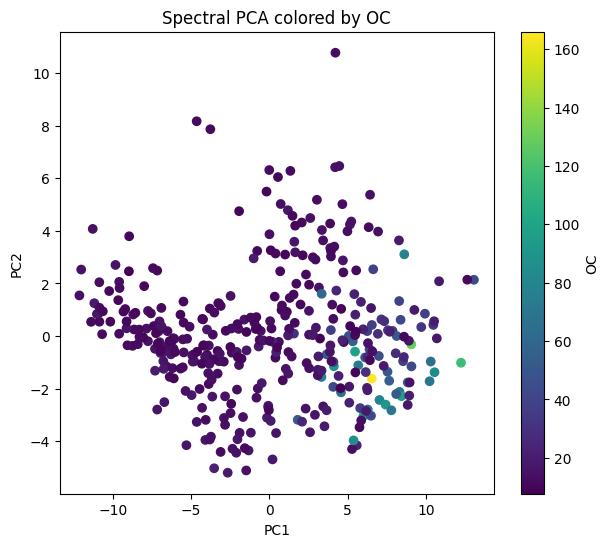

In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1],
            c=targets["OC"],
            cmap="viridis")

plt.colorbar(label="OC")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Spectral PCA colored by OC")
plt.show()


# STEP 5.5 — Cluster the spectra

I identify natural soil groups.
Run k-means clustering

In [ ]:
from sklearn.cluster import KMeans

k = 5   # good starting point
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_pca)

meta["cluster"] = clusters


/tmp/ipython-input-1408335261.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  meta["cluster"] = clusters


# STEP 5.6 — Visualize clusters

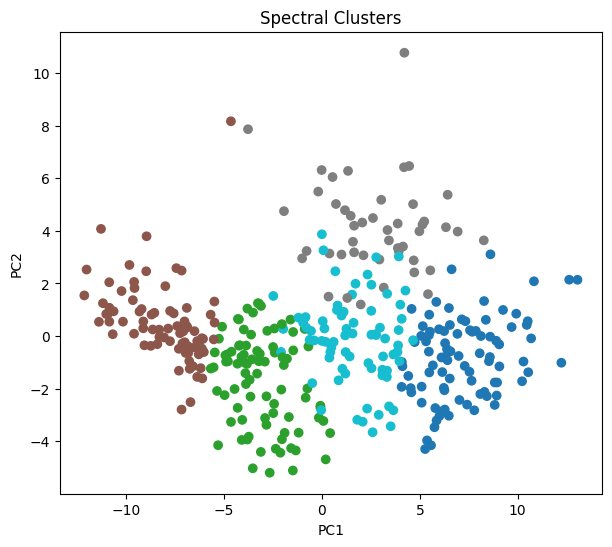

In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="tab10")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Spectral Clusters")
plt.show()


# STEP 5.7 — Cluster composition analysis

This is VERY insightful.

Cluster summary

In [ ]:


df_cluster = meta.join(targets)   # meta has Fcode, CODE, cluster; targets are numeric

numeric_cols = df_cluster.select_dtypes(include="number").columns
cluster_summary = df_cluster.groupby("cluster")[numeric_cols].mean()

cluster_summary



,idx,cluster,PH,OC,P,K,Mg,Ca,Na,MC,CEC
cluster,,,,,,,,,,,
0,189.528090,0.0,7.375281,40.368539,26.382022,28.483146,59.966292,1227.449438,5.668539,25.361204,67.346410
1,123.720930,1.0,6.788372,13.894186,28.639535,34.302326,19.767442,273.197674,8.122093,16.665812,16.540101
2,165.794872,2.0,6.724359,13.078205,23.871795,30.871795,18.807692,271.307692,6.003846,20.296513,16.185092
3,260.086957,3.0,7.613043,13.353261,33.847826,24.391304,64.586957,1956.543478,4.802174,19.676429,104.043521
4,232.520548,4.0,7.509589,17.545205,30.712329,30.123288,61.602740,1810.178082,6.263014,17.804524,96.687390


Add sample counts per cluster

In [ ]:
cluster_counts = df_cluster.groupby("cluster").size().rename("n_samples")
cluster_counts


,n_samples
cluster,
0,89
1,86
2,78
3,46
4,73


See which sites dominate each cluster (strings handled correctly)

In [ ]:
pd.crosstab(meta["cluster"], meta["Fcode"])


Fcode,Bee,Bot,Dal,Fab,Gin,Gra,Gro,Kat,Kro,Mor,Thi,Wat
cluster,,,,,,,,,,,,
0,4,0,3,1,0,27,0,0,24,29,0,1
1,1,10,18,0,12,0,24,8,0,0,13,0
2,2,14,0,0,20,0,33,9,0,0,0,0
3,28,0,0,3,0,0,0,0,0,0,0,15
4,4,1,2,21,6,5,3,3,22,2,0,4


And proportions (even better):

In [ ]:
pd.crosstab(meta["cluster"], meta["Fcode"], normalize="index").round(3)


Fcode,Bee,Bot,Dal,Fab,Gin,Gra,Gro,Kat,Kro,Mor,Thi,Wat
cluster,,,,,,,,,,,,
0,0.045,0.000,0.034,0.011,0.000,0.303,0.000,0.000,0.270,0.326,0.000,0.011
1,0.012,0.116,0.209,0.000,0.140,0.000,0.279,0.093,0.000,0.000,0.151,0.000
2,0.026,0.179,0.000,0.000,0.256,0.000,0.423,0.115,0.000,0.000,0.000,0.000
3,0.609,0.000,0.000,0.065,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.326
4,0.055,0.014,0.027,0.288,0.082,0.068,0.041,0.041,0.301,0.027,0.000,0.055


Most common site per cluster (quick)

In [ ]:
top_site = df_cluster.groupby("cluster")["Fcode"].agg(lambda x: x.value_counts().index[0])
top_site


,Fcode
cluster,
0,Mor
1,Gro
2,Gro
3,Bee
4,Kro


# 6.1 Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np


# Step 6 — GANS Training Design

# Step 6.1 — Build the conditioning matrix C

In [ ]:
import numpy as np
import pandas as pd

# X_GAN: (N, L) scaled to [-1,1] using smoothed reflectance
# meta["cluster"]: integers 0..4
# targets: DataFrame with columns ["OC","MC","CEC"]

clusters = meta["cluster"].to_numpy().astype(int)
k = clusters.max() + 1  # should be 5

# one-hot cluster
C_cluster = np.eye(k, dtype=np.float32)[clusters]  # (N, 5)

# continuous conditions (z-score)
cont = targets[["OC","MC","CEC"]].to_numpy(dtype=np.float32)  # (N,3)
cont_mean = cont.mean(axis=0, keepdims=True)
cont_std  = cont.std(axis=0, keepdims=True) + 1e-8
C_cont = (cont - cont_mean) / cont_std

# final condition vector
C = np.concatenate([C_cluster, C_cont], axis=1).astype(np.float32)  # (N, 8)

print("X_GAN:", X_GAN.shape, "C:", C.shape)


X_GAN: (372, 1321) C: (372, 8)


# Step 6.2 : PyTorch Dataset + DataLoader

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class SpectraDataset(Dataset):
    def __init__(self, X, C):
        self.X = torch.tensor(X, dtype=torch.float32)  # (N, L)
        self.C = torch.tensor(C, dtype=torch.float32)  # (N, Cdim)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.C[idx]

dataset = SpectraDataset(X_GAN, C)
loader = DataLoader(dataset, batch_size=32, shuffle=True, drop_last=True)


# Step 6.3 Model: Conditional Generator + Conditional Critic (WGAN-GP)

This design uses upsample + Conv1D (stable for 1D spectra) and injects condition by concatenating it as extra channels.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import math

def tile_condition(c, length):
    # c: (B, Cdim) -> (B, Cdim, length)
    return c.unsqueeze(-1).repeat(1, 1, length)

class Generator(nn.Module):
    def __init__(self, z_dim, c_dim, out_len, base_ch=128):
        super().__init__()
        self.z_dim = z_dim
        self.c_dim = c_dim
        self.out_len = out_len

        # start from a short sequence then upsample
        self.init_len = 80  # adjust if you want
        self.fc = nn.Sequential(
            nn.Linear(z_dim + c_dim, base_ch * self.init_len),
            nn.BatchNorm1d(base_ch * self.init_len),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.conv1 = nn.Sequential(
            nn.Conv1d(base_ch + c_dim, base_ch, 5, padding=2),
            nn.BatchNorm1d(base_ch),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(base_ch + c_dim, base_ch//2, 5, padding=2),
            nn.BatchNorm1d(base_ch//2),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(base_ch//2 + c_dim, base_ch//4, 5, padding=2),
            nn.BatchNorm1d(base_ch//4),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.out = nn.Conv1d(base_ch//4 + c_dim, 1, 7, padding=3)

    def forward(self, z, c):
        # z: (B, z_dim), c: (B, c_dim)
        x = torch.cat([z, c], dim=1)
        x = self.fc(x)
        x = x.view(x.size(0), -1, self.init_len)  # (B, base_ch, init_len)

        # progressively upsample to reach out_len
        # upsample 1
        x = F.interpolate(x, scale_factor=2, mode="linear", align_corners=False)  # len ~160
        x = torch.cat([x, tile_condition(c, x.size(-1))], dim=1)
        x = self.conv1(x)

        # upsample 2
        x = F.interpolate(x, scale_factor=2, mode="linear", align_corners=False)  # len ~320
        x = torch.cat([x, tile_condition(c, x.size(-1))], dim=1)
        x = self.conv2(x)

        # upsample 3
        x = F.interpolate(x, scale_factor=2, mode="linear", align_corners=False)  # len ~640
        x = torch.cat([x, tile_condition(c, x.size(-1))], dim=1)
        x = self.conv3(x)

        # final resize exactly to out_len
        x = F.interpolate(x, size=self.out_len, mode="linear", align_corners=False)
        x = torch.cat([x, tile_condition(c, x.size(-1))], dim=1)
        x = self.out(x)

        return torch.tanh(x).squeeze(1)  # (B, out_len) in [-1,1]

class Critic(nn.Module):
    def __init__(self, c_dim, in_len, base_ch=64):
        super().__init__()
        self.c_dim = c_dim
        self.in_len = in_len

        def block(in_ch, out_ch, k=5, s=2, p=2):
            return nn.Sequential(
                nn.Conv1d(in_ch, out_ch, k, stride=s, padding=p),
                nn.LeakyReLU(0.2, inplace=True),
            )

        # Input: spectrum as 1 channel + condition channels
        self.b1 = block(1 + c_dim, base_ch)        # downsample
        self.b2 = block(base_ch + c_dim, base_ch*2)
        self.b3 = block(base_ch*2 + c_dim, base_ch*4)
        self.b4 = block(base_ch*4 + c_dim, base_ch*4)

        # compute final length after 4 stride-2 downsamples (approx)
        # We'll global-pool instead of relying on exact length.
        self.fc = nn.Linear(base_ch*4, 1)

    def forward(self, x, c):
        # x: (B, L) in [-1,1]
        x = x.unsqueeze(1)  # (B,1,L)

        x = torch.cat([x, tile_condition(c, x.size(-1))], dim=1)
        x = self.b1(x)

        x = torch.cat([x, tile_condition(c, x.size(-1))], dim=1)
        x = self.b2(x)

        x = torch.cat([x, tile_condition(c, x.size(-1))], dim=1)
        x = self.b3(x)

        x = torch.cat([x, tile_condition(c, x.size(-1))], dim=1)
        x = self.b4(x)

        # global average pool over length
        x = x.mean(dim=-1)  # (B, ch)
        return self.fc(x).squeeze(1)  # (B,)


# Step 6.4 WGAN-GP gradient penalty + smoothness loss

In [ ]:
def gradient_penalty(critic, real, fake, c, device, gp_lambda=10.0):
    B = real.size(0)
    eps = torch.rand(B, 1, device=device)
    eps = eps.expand_as(real)
    x_hat = eps * real + (1 - eps) * fake
    x_hat.requires_grad_(True)

    d_hat = critic(x_hat, c)
    grads = torch.autograd.grad(
        outputs=d_hat,
        inputs=x_hat,
        grad_outputs=torch.ones_like(d_hat),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]  # (B, L)

    grad_norm = grads.view(B, -1).norm(2, dim=1)
    gp = gp_lambda * ((grad_norm - 1) ** 2).mean()
    return gp

def smoothness_loss(x):
    # x: (B, L) in [-1,1]
    # second difference Δ²x
    d2 = x[:, 2:] - 2*x[:, 1:-1] + x[:, :-2]
    return (d2 ** 2).mean()


# Step 6.5 Training loop (stable defaults)

In [ ]:
import torch
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

N, L = X_GAN.shape
z_dim = 128
c_dim = C.shape[1]

G = Generator(z_dim=z_dim, c_dim=c_dim, out_len=L).to(device)
D = Critic(c_dim=c_dim, in_len=L).to(device)

lr = 1e-4
opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.0, 0.9))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.0, 0.9))

n_critic = 4        # reduce critic pressure
gp_lambda = 10      # keep stable
alpha_smooth = 2.0  # encourage smooth spectra
steps = 2600  # good start; increase later
step = 0

G.train(); D.train()

while step < steps:
    for real_x, c in loader:
        if step >= steps:
            break

        real_x = real_x.to(device)   # (B,L)
        c = c.to(device)             # (B,Cdim)
        B = real_x.size(0)

        # ---------------------
        # Train Critic n_critic times
        # ---------------------
        for _ in range(n_critic):
            z = torch.randn(B, z_dim, device=device)
            with torch.no_grad():
                fake_x = G(z, c)

            D_real = D(real_x, c).mean()
            D_fake = D(fake_x, c).mean()
            gp = gradient_penalty(D, real_x, fake_x, c, device, gp_lambda=gp_lambda)

            loss_D = -(D_real - D_fake) + gp

            opt_D.zero_grad(set_to_none=True)
            loss_D.backward()
            opt_D.step()

        # ---------------------
        # Train Generator
        # ---------------------
        z = torch.randn(B, z_dim, device=device)
        fake_x = G(z, c)
        loss_adv = -D(fake_x, c).mean()
        loss_smooth = smoothness_loss(fake_x)
        loss_G = loss_adv + alpha_smooth * loss_smooth

        opt_G.zero_grad(set_to_none=True)
        loss_G.backward()
        opt_G.step()

        if step % 200 == 0:
            print(f"step={step:4d}  D={loss_D.item():.3f}  G={loss_G.item():.3f}  adv={loss_adv.item():.3f}  smooth={loss_smooth.item():.8f}")

        step += 1


step=   0  D=9.961  G=-0.017  adv=-0.017  smooth=0.00014400
step= 200  D=-1.646  G=24.747  adv=24.747  smooth=0.00012459
step= 400  D=-4.647  G=93.677  adv=93.677  smooth=0.00014363
step= 600  D=-6.142  G=124.328  adv=124.327  smooth=0.00015465
step= 800  D=-3.391  G=138.339  adv=138.339  smooth=0.00012583
step=1000  D=-3.025  G=195.002  adv=195.002  smooth=0.00012339
step=1200  D=-1.352  G=220.717  adv=220.716  smooth=0.00013528
step=1400  D=-2.938  G=207.180  adv=207.180  smooth=0.00011404
step=1600  D=-4.368  G=222.616  adv=222.616  smooth=0.00013228
step=1800  D=-2.683  G=247.900  adv=247.900  smooth=0.00011425
step=2000  D=-4.653  G=281.891  adv=281.890  smooth=0.00010026
step=2200  D=-1.666  G=260.068  adv=260.068  smooth=0.00008079
step=2400  D=-2.866  G=286.284  adv=286.284  smooth=0.00009612


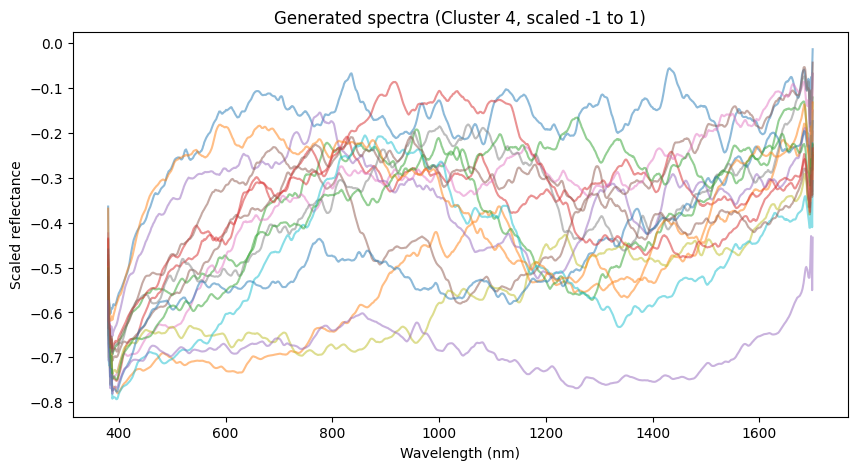

In [ ]:
import matplotlib.pyplot as plt
import torch

G.eval()
with torch.no_grad():
    c_req = make_condition(cluster_id=4, oc=17.0, mc=18.0, cec=95.0).to(device)
    z = torch.randn(16, z_dim, device=device)
    fake = G(z, c_req.repeat(16,1)).cpu().numpy()

plt.figure(figsize=(10,5))
for i in range(16):
    plt.plot(wavelengths2, fake[i], alpha=0.5)
plt.title("Generated spectra (Cluster 4, scaled -1 to 1)")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Scaled reflectance")
plt.show()

Quick plot block

# Step 6.6: Generate spectra for a chosen cluster + target chemistry

In [ ]:
def make_condition(cluster_id, oc, mc, cec):
    # one-hot cluster
    onehot = np.zeros((1, k), dtype=np.float32)
    onehot[0, cluster_id] = 1.0

    cont = np.array([[oc, mc, cec]], dtype=np.float32)
    cont = (cont - cont_mean) / cont_std  # z-score

    c = np.concatenate([onehot, cont], axis=1)
    return torch.tensor(c, dtype=torch.float32)

G.eval()
with torch.no_grad():
    c_req = make_condition(cluster_id=4, oc=17.0, mc=18.0, cec=95.0).to(device)
    z = torch.randn(10, z_dim, device=device)
    c_batch = c_req.repeat(10, 1)
    fake = G(z, c_batch).cpu().numpy()  # (10, L) in [-1,1]
print(fake.shape)

(10, 1321)


# To invert scaling back to reflectance (if you saved xmin/xmax):

In [ ]:
# xmin, xmax from your GAN scaling
fake_reflectance = (fake + 1) / 2 * (xmax - xmin + 1e-8) + xmin

# Apply Savitzky–Golay smoothing

In [ ]:
from scipy.signal import savgol_filter

# Apply smoothing to generated spectra
fake_smooth = savgol_filter(
    fake,            # generated spectra
    window_length=11,  # must be odd
    polyorder=2,
    axis=1
)

print("Smoothing complete")

Smoothing complete


# Smooth vs RAW ANS Gnerated

In [ ]:
import matplotlib.pyplot as plt

def overlay_plot(real, fake, title, n_plot=10):
    plt.figure(figsize=(10,5))

    # plot real spectra (gray)
    for i in range(min(n_plot, real.shape[0])):
        plt.plot(wavelengths2, real[i], color="gray", alpha=0.3)

    # plot generated spectra (colored)
    for i in range(min(n_plot, fake.shape[0])):
        plt.plot(wavelengths2, fake[i], alpha=0.8)

    plt.title(title)
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Scaled reflectance [-1,1]")
    plt.show()

In [ ]:
overlay_plot(real[:10], fake[:10],
            "RAW Generated")

overlay_plot(real[:10], fake_smooth[:10],
            "Smoothed Generated")

NameError: name 'real' is not defined

# Step 7 : Synthetic Spectral Library Expansion (Cluster-wise)

#Step 7.1: Utility functions (generate → smooth → quality filter)

In [ ]:
import numpy as np
import torch
from scipy.signal import savgol_filter

def spike_score_batch(X):
    d2 = X[:, 2:] - 2*X[:, 1:-1] + X[:, :-2]
    return np.mean(d2**2, axis=1)

def generate_fake_cluster(cluster_id, n_gen, oc=None, mc=None, cec=None, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.where(meta["cluster"].to_numpy() == cluster_id)[0]
    if len(idx) == 0:
        raise ValueError(f"No samples in cluster {cluster_id}")

    # default condition = cluster means
    if oc is None:  oc  = float(targets.loc[idx, "OC"].mean())
    if mc is None:  mc  = float(targets.loc[idx, "MC"].mean())
    if cec is None: cec = float(targets.loc[idx, "CEC"].mean())

    G.eval()
    with torch.no_grad():
        c_req = make_condition(cluster_id=cluster_id, oc=oc, mc=mc, cec=cec).to(device)
        z = torch.randn(n_gen, z_dim, device=device)
        fake = G(z, c_req.repeat(n_gen, 1)).cpu().numpy()

    return fake, (oc, mc, cec)

def smooth_and_filter(fake, real_ref, window=11, poly=2, thr_mult=3.0):
    # smooth
    fake_s = savgol_filter(fake, window_length=window, polyorder=poly, axis=1)

    # compute spike scores
    real_scores = spike_score_batch(real_ref)
    fake_scores = spike_score_batch(fake_s)

    thr = thr_mult * np.median(real_scores)
    keep = fake_scores <= thr

    return fake_s[keep], {
        "kept": int(np.sum(keep)),
        "total": int(fake.shape[0]),
        "thr": float(thr),
        "median_real": float(np.median(real_scores)),
        "median_fake": float(np.median(fake_scores)),
        "median_ratio": float(np.median(fake_scores)/(np.median(real_scores)+1e-12))
    }

# Step 7.2: Generate a synthetic library for ALL clusters

In [ ]:
n_per_cluster = 500          # change if needed
thr_mult = 3.0               # strict; try 5.0 if too many are removed

synthetic_lib = []
summary = []

for cluster_id in sorted(meta["cluster"].unique()):
    idx = np.where(meta["cluster"].to_numpy() == cluster_id)[0]
    real_ref = X_GAN[idx]   # reference real spectra for this cluster

    # generate
    fake, cond_used = generate_fake_cluster(cluster_id, n_per_cluster)

    # smooth + filter
    fake_clean, stats = smooth_and_filter(fake, real_ref, thr_mult=thr_mult)

    # store
    synthetic_lib.append(fake_clean)

    summary.append({
        "cluster": int(cluster_id),
        "cond_OC": cond_used[0],
        "cond_MC": cond_used[1],
        "cond_CEC": cond_used[2],
        "kept": stats["kept"],
        "total": stats["total"],
        "kept_pct": 100 * stats["kept"] / max(1, stats["total"]),
        "median_ratio_after_smooth": stats["median_ratio"],
        "median_real_spike": stats["median_real"],
        "median_fake_spike": stats["median_fake"],
    })

# combine all synthetic spectra
X_SYN = np.vstack(synthetic_lib)
print("✅ Total synthetic spectra kept:", X_SYN.shape[0])

✅ Total synthetic spectra kept: 483


# Step 7.3: To View the summary table

In [ ]:
import pandas as pd
summary_df = pd.DataFrame(summary).sort_values("cluster")
summary_df

,cluster,cond_OC,cond_MC,cond_CEC,kept,total,kept_pct,median_ratio_after_smooth,median_real_spike,median_fake_spike
0,0,40.368539,25.361204,67.346410,0,500,0.0,12.257458,1.382514e-07,0.000002
1,1,13.894186,16.665812,16.540101,52,500,10.4,4.094798,3.230761e-07,0.000001
2,2,13.078205,20.296513,16.185092,276,500,55.2,2.910750,5.647634e-07,0.000002
3,3,13.353261,19.676429,104.043521,155,500,31.0,3.330364,3.675847e-07,0.000001
4,4,17.545205,17.804524,96.687390,0,500,0.0,5.320925,2.578779e-07,0.000001


# Step 7.4: Create the synthetic “meta + targets” for augmentation

label synthetic samples with the same conditioning values (cluster mean OC/MC/CEC).

In [ ]:
rows = []
for row in summary:
    n_k = int(row["kept"])
    rows.append(pd.DataFrame({
        "is_synthetic": 1,
        "cluster": row["cluster"],
        "OC": row["cond_OC"],
        "MC": row["cond_MC"],
        "CEC": row["cond_CEC"],
    }, index=np.arange(n_k)))

syn_targets = pd.concat(rows, ignore_index=True)

print("X_SYN:", X_SYN.shape)
print("syn_targets:", syn_targets.shape)

X_SYN: (483, 1321)
syn_targets: (483, 5)


# Step 7.5: Quick final plot check (one cluster)

I now have:

1) X_SYN ; Synthetic spectra matrix (same format as X_GAN)

2) syn_targets; Synthetic labels for OC/MC/CEC and cluster

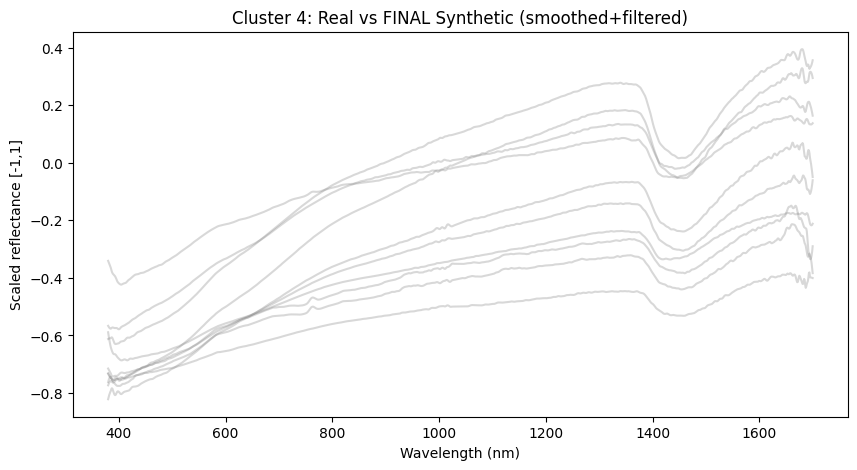

In [ ]:
cluster_id = 4
idx = np.where(meta["cluster"].to_numpy() == cluster_id)[0]
real_ref = X_GAN[idx]

# find synthetic part for that cluster
syn_idx = np.where(syn_targets["cluster"].to_numpy() == cluster_id)[0]
fake_show = X_SYN[syn_idx[:10]]

overlay_plot(real_ref[:10], fake_show, f"Cluster {cluster_id}: Real vs FINAL Synthetic (smoothed+filtered)")

# Step 8: Augmentation Experiment (Real vs Real+Synthetic)

# 8.1 Prepare the real dataset

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

y = targets[["OC","MC","CEC"]].copy()

X_train_real, X_test, y_train_real, y_test = train_test_split(
    X_GAN, y,
    test_size=0.2,
    random_state=42
)

print("Real train:", X_train_real.shape, "Real test:", X_test.shape)

Real train: (297, 1321) Real test: (75, 1321)


# 8.2 Build synthetic dataset aligned with your labels

In [ ]:
X_syn = X_SYN
y_syn = syn_targets[["OC","MC","CEC"]].copy()

print("Synthetic:", X_syn.shape, y_syn.shape)

Synthetic: (483, 1321) (483, 3)


# 8.3 Combine (Real + Synthetic) ONLY for training

In [ ]:
import pandas as pd

X_train_aug = np.vstack([X_train_real, X_syn])
y_train_aug = pd.concat([y_train_real, y_syn], ignore_index=True)

print("Augmented train:", X_train_aug.shape, y_train_aug.shape)

Augmented train: (780, 1321) (780, 3)


#8.4 Train and evaluate models (Random Forest)

 train 2 models:
A) Real-only model
B) Real+Synthetic model

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def eval_model(model, Xtr, ytr, Xte, yte, name="Model"):
    out = []
    model.fit(Xtr, ytr)

    pred = model.predict(Xte)

    for i, col in enumerate(yte.columns):
        rmse = np.sqrt(mean_squared_error(yte[col], pred[:, i]))
        mae  = mean_absolute_error(yte[col], pred[:, i])
        r2   = r2_score(yte[col], pred[:, i])
        out.append([name, col, rmse, mae, r2])

    return out

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    max_features="sqrt"
)

results = []
results += eval_model(rf, X_train_real, y_train_real, X_test, y_test, name="RF Real-only")
results += eval_model(rf, X_train_aug,  y_train_aug,  X_test, y_test, name="RF Real+Synthetic")

import pandas as pd
res_df = pd.DataFrame(results, columns=["Model","Target","RMSE","MAE","R2"]).sort_values(["Target","Model"])
res_df

,Model,Target,RMSE,MAE,R2
5,RF Real+Synthetic,CEC,40.404159,25.611201,0.192521
2,RF Real-only,CEC,40.032317,26.211792,0.207315
4,RF Real+Synthetic,MC,5.306628,3.911472,0.430406
1,RF Real-only,MC,5.035915,3.696448,0.487039
3,RF Real+Synthetic,OC,7.159682,4.486407,0.667199
0,RF Real-only,OC,6.784186,4.559900,0.701192


# 8.5 Percent improvement table

In [ ]:
improve = []

for t in ["OC","MC","CEC"]:
    r_real = res_df[(res_df.Target==t) & (res_df.Model=="RF Real-only")].iloc[0]
    r_aug  = res_df[(res_df.Target==t) & (res_df.Model=="RF Real+Synthetic")].iloc[0]

    rmse_imp = 100 * (r_real.RMSE - r_aug.RMSE) / r_real.RMSE
    r2_imp   = r_aug.R2 - r_real.R2

    improve.append([t, rmse_imp, r2_imp])

imp_df = pd.DataFrame(improve, columns=["Target","RMSE_%_improvement","R2_gain"])
imp_df

,Target,RMSE_%_improvement,R2_gain
0,OC,-5.534871,-0.033993
1,MC,-5.375663,-0.056632
2,CEC,-0.928854,-0.014794


# 8.6 Plot predicted vs observed

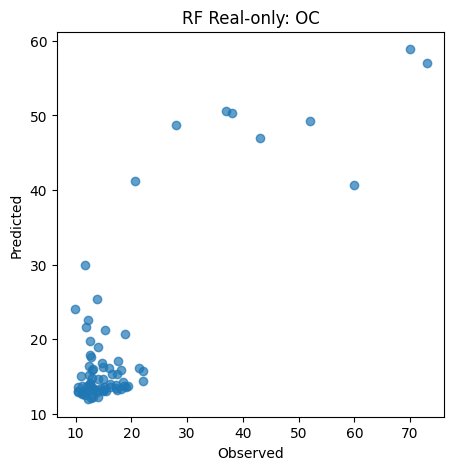

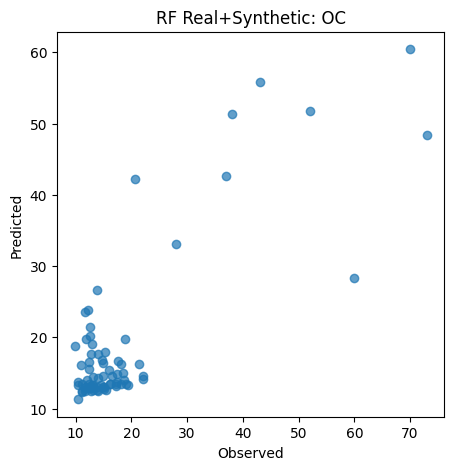

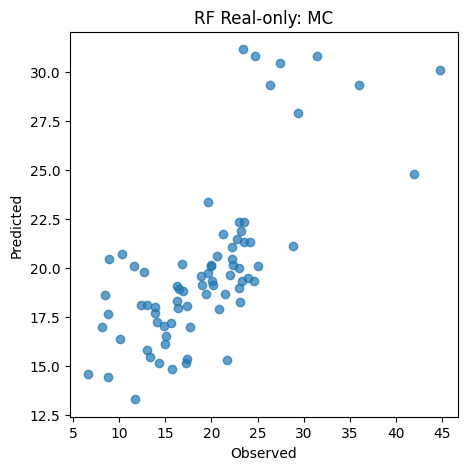

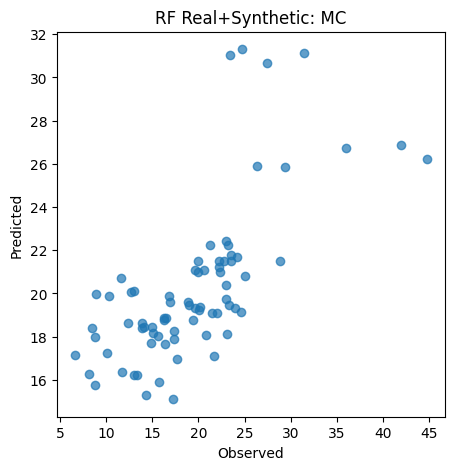

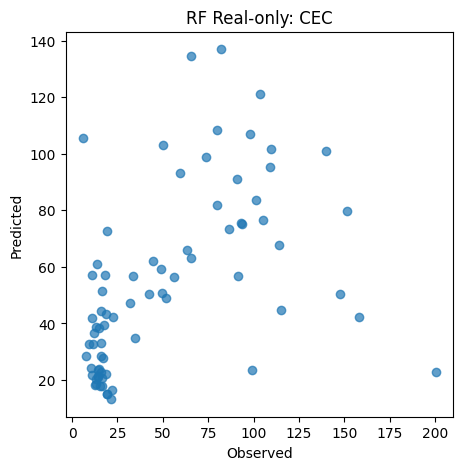

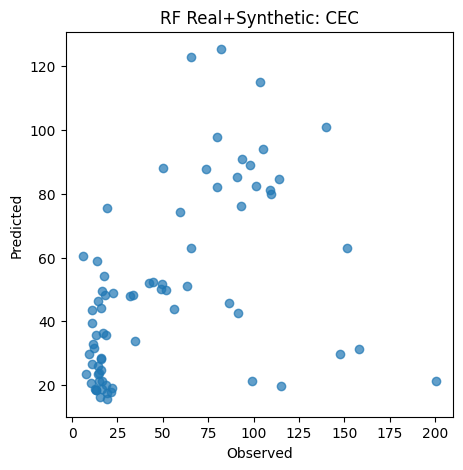

In [ ]:
import matplotlib.pyplot as plt

def plot_pred(y_true, y_pred, title):
    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred, alpha=0.7)
    plt.xlabel("Observed")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.show()

# Fit both models once more to get predictions for plotting
rf_real = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1, max_features="sqrt")
rf_aug  = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1, max_features="sqrt")

rf_real.fit(X_train_real, y_train_real)
rf_aug.fit(X_train_aug, y_train_aug)

pred_real = rf_real.predict(X_test)
pred_aug  = rf_aug.predict(X_test)

for i, t in enumerate(["OC","MC","CEC"]):
    plot_pred(y_test[t].values, pred_real[:,i], f"RF Real-only: {t}")
    plot_pred(y_test[t].values, pred_aug[:,i],  f"RF Real+Synthetic: {t}")